<a href="https://colab.research.google.com/github/tlfletcher17/glovedesign/blob/main/make_fpcbs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#!pip show protobuf

In [3]:
!pip install mediapipe

In [2]:
#Cell 2
from google.colab import output
output.enable_custom_widget_manager()

In [3]:
#Cell 3
# Download the official MIT folder into this workspace
# !git clone https://github.com/devinmur29/fpcb-glove-design.git
!git clone https://github.com/tlfletcher17/fpcb-glove-design.git
%cd fpcb-glove-design

# Install the tools without breaking our mediapipe fix
!pip install --no-cache-dir scikit-rf shapely svgpathtools svg2mod ipympl

fatal: destination path 'fpcb-glove-design' already exists and is not an empty directory.
/content/fpcb-glove-design


In [2]:
!pip install --force-reinstall protobuf==3.20.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.3
    Uninstalling protobuf-4.25.3:
      Successfully uninstalled protobuf-4.25.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.14 requires protobuf<5,>=4.25.3, but you have protobuf 3.20.3 which is incompatible.
google-cloud-speech 2.40.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-trace 1.19.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-language 2.20.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-spanner 3.67.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
ydf 0.15.0 requires protobuf

In [4]:
# !pip install --force-reinstall mediapipe==0.10.11 protobuf==4.25.3
!pip install --force-reinstall mediapipe==0.10.14 protobuf==4.25.3

  Using cached mediapipe-0.10.14-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.7 kB)
  Using cached protobuf-4.25.3-cp37-abi3-manylinux2014_x86_64.whl.metadata (541 bytes)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached jax-0.10.2-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.10.2-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (1.3 kB)
  Using cached matplotlib-3.11.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (80 kB)
  Using cached numpy-2.4.6-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached sounddevice-0.5.5-py3-none-any.whl.metadata (1.4 kB)
  Using cached cffi-2.0.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_

In [1]:
#Cell 4
import cv2
import matplotlib.pyplot as plt
from mediapipe.python.solutions import hands as mp_hands
from mediapipe.python.solutions import drawing_utils as mp_draw

#import mediapipe as mp
#import cv2
#import matplotlib.pyplot as plt


ImportError: cannot import name 'runtime_version' from 'google.protobuf' (/usr/local/lib/python3.12/dist-packages/google/protobuf/__init__.py)

In [5]:
# import os
# os.kill(os.getpid(), 9)

In [2]:
#Cell 5
#import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from skimage import measure
import imageio
from mediapipe.python.solutions import hands as mp_hands
from mediapipe.python.solutions import drawing_utils as mp_draw
import matplotlib.patches as patches
import cv2
import numpy as np
from matplotlib.patches import Polygon as axPolygon
from matplotlib.widgets import Button
from IPython.display import display, clear_output
import json
from shapely.geometry import LineString, Point, MultiPolygon
from shapely.geometry import Polygon as shapPolygon
import itertools
import svgwrite
from shapely.geometry.polygon import orient
from shapely.ops import unary_union
from lxml import etree
from svg2mod.importer import Svg2ModImport
from svg2mod.exporter import Svg2ModExportLatest, DEFAULT_DPI
import os
import sys
import shlex
import ipywidgets
#import ipympl



## Crop Hand to Paper and Extract Pixel to Inch Conversion

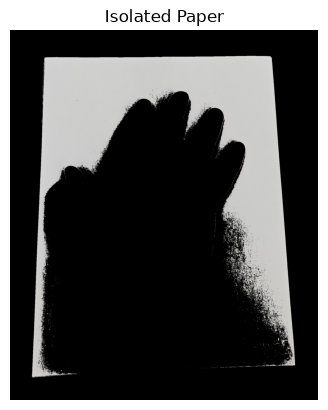

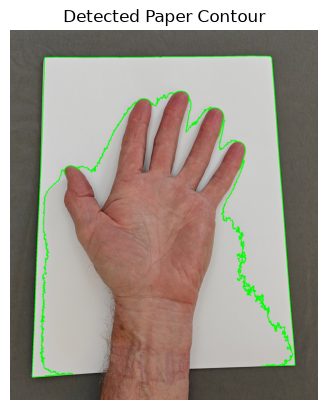

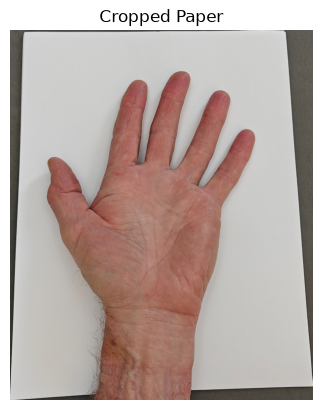

1.2217105263157895
1.2941176470588236
Pixels per cm (width): 70.40296433534044
Pixels per cm (height): 66.46385110952039


In [3]:
#Cell 6

import numpy as np
#Unedited hand
# originalHand = 'righthandflip.jpg'
originalHand = '/content/fpcb-glove-design/Lefthand0515.jpg'

# Step 1: Load the image
image = cv2.imread(originalHand)

# Step 2: Convert to HSV color space
hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Step 3: Define the range for white in HSV
lower_white = np.array([0, 0, 200])  # Minimum hue, saturation, and value
upper_white = np.array([250, 60, 255])  # Maximum hue, saturation, and value

# Step 4: Create a mask
mask = cv2.inRange(hsv_image, lower_white, upper_white)

# Step 5: Apply the mask to isolate the paper
isolated_paper = cv2.bitwise_and(image, image, mask=mask)

# Display the isolated paper
plt.imshow(cv2.cvtColor(isolated_paper, cv2.COLOR_BGR2RGB))
plt.title("Isolated Paper")
plt.axis("off")
plt.show()

# Step 6: Find contours in the mask
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Step 7: Identify the largest contour (likely the paper)
paper_contour = max(contours, key=cv2.contourArea)

# Step 8: Draw the contour on the original image for visualization
contoured_image = image.copy()
cv2.drawContours(contoured_image, [paper_contour], -1, (0, 255, 0), 3)

# Display the result with contour
plt.imshow(cv2.cvtColor(contoured_image, cv2.COLOR_BGR2RGB))
plt.title("Detected Paper Contour")
plt.axis("off")
plt.show()

# Step 9: Get the bounding box of the paper
x, y, w, h = cv2.boundingRect(paper_contour)

# Step 10: Crop the paper from the image, save the image
cropped_paper = image[y:y+h, x:x+w]
cv2.imwrite("croppedHandleft.jpg", cropped_paper)

# Display the cropped paper
plt.imshow(cv2.cvtColor(cropped_paper, cv2.COLOR_BGR2RGB))
plt.title("Cropped Paper")
plt.axis("off")
plt.show()

# Step 11: Calculate the pixel-to-inch ratio based on known paper size (8.5x11 inches)
paper_width_cm = 8.5 * 2.54  # Width of paper in cm
paper_height_cm = 11.0 * 2.54  # Height of paper in cm

# Get the pixel dimensions of the cropped paper
pixel_height, pixel_width, _ = cropped_paper.shape
print(pixel_height/pixel_width)
print(11/8.5)

# Calculate pixels per inch for both width and height
pixels_per_cm_width = pixel_width / paper_width_cm
pixels_per_cm_height = pixel_height / paper_height_cm

# Print out the pixel-to-inch ratios
print(f"Pixels per cm (width): {pixels_per_cm_width}")
print(f"Pixels per cm (height): {pixels_per_cm_height}")





## Extract Contour, Identify Key Points, Create Sensing Regions

In [ ]:
!pip install --upgrade mediapipe

In [ ]:
#Cell DO NOT RUN NOW
!pip install --force-reinstall mediapipe protobuf

  Using cached mediapipe-0.10.35-py3-none-manylinux_2_28_x86_64.whl.metadata (9.8 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached sounddevice-0.5.5-py3-none-any.whl.metadata (1.4 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 4.9 MB/s eta 0:00:00
Using cached mediapipe-0.10.35-py3-none-manylinux_2_28_x86_64.whl (12.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 12.2 MB/s eta 0:00:00
Using cached absl_py-2.4.0-py3-none-any.whl (135 kB)
Using cached sounddevice-0.5.5-py3-none-any.whl (32 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.7/135.7 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.2/79.2 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [6]:
!pip install --force-reinstall protobuf==3.20.3

  Using cached protobuf-3.20.3-py2.py3-none-any.whl.metadata (720 bytes)
Using cached protobuf-3.20.3-py2.py3-none-any.whl (162 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.14 requires protobuf<5,>=4.25.3, but you have protobuf 3.20.3 which is incompatible.
google-cloud-speech 2.40.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-trace 1.19.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-language 2.20.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-spanner 3.67.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3

In [2]:
!pip install --upgrade mediapipe protobuf

  Using cached mediapipe-0.10.35-py3-none-manylinux_2_28_x86_64.whl.metadata (9.8 kB)
Using cached mediapipe-0.10.35-py3-none-manylinux_2_28_x86_64.whl (12.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 6.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
  Attempting uninstall: mediapipe
    Found existing installation: mediapipe 0.10.14
    Uninstalling mediapipe-0.10.14:
      Successfully uninstalled mediapipe-0.10.14
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.35.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35

/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


(1857, 1520, 3)


/tmp/ipykernel_20929/3231203922.py:119: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


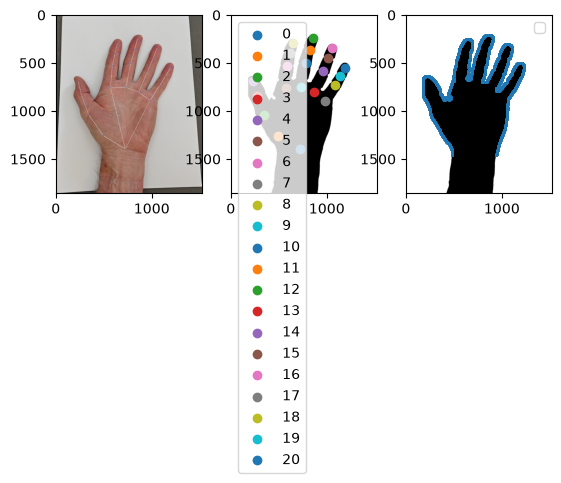

In [4]:
#Cell 7
from skimage import measure
# Set path to hand mask (obtained from illustrator),
# distance from hand landmark 0 for bottom traces (cm)
# distance from hand landmark 0 for bottom edge cut (cm)
#cropped_mask_path = "croppedHandright0429.jpg"
cropped_mask_path = '/content/fpcb-glove-design/croppedHandleftmask.jpg'
trace_start_distance = 1
bottom_edge_distance = 2

def smooth_hand_mask(binary_mask, blur_kernel_size=5, morph_kernel_size=3):
    """
    Smooths out the hand binary mask by applying Gaussian blur and morphological operations.
    :param binary_mask: 2D binary mask (1s for hand, 0s for background).
    :param blur_kernel_size: Size of the kernel for Gaussian blur.
    :param morph_kernel_size: Size of the kernel for morphological operations.
    :return: Smoothed binary mask.
    """
    # Apply Gaussian blur to smooth out local details
    smoothed_mask = cv2.GaussianBlur(binary_mask, (blur_kernel_size, blur_kernel_size), 0)

    # Threshold the image to convert it back to binary after blurring
    _, smoothed_mask = cv2.threshold(smoothed_mask, 127, 255, cv2.THRESH_BINARY)

    # Create a kernel for morphological operations (a square or elliptical kernel works well)
    kernel = np.ones((morph_kernel_size, morph_kernel_size), np.uint8)

    # Apply morphological opening (erosion followed by dilation) to remove small noise
    smoothed_mask = cv2.morphologyEx(smoothed_mask, cv2.MORPH_OPEN, kernel)

    # Optionally, apply closing (dilation followed by erosion) to fill small gaps
    smoothed_mask = cv2.morphologyEx(smoothed_mask, cv2.MORPH_CLOSE, kernel)

    return smoothed_mask


def contour_hand(binary_image, boundary=-1, num_points=1000):

    binary_image = binary_image[:boundary, :]
    binary_image = binary_image.sum(-1) / binary_image.sum(-1).max()

    # Find contours in the binary image
    contours = measure.find_contours(binary_image, level=0.5)

    points = []
    line_segments = []
    contours = [contours[0]]
    for contour in contours:
        distances = np.sqrt(np.sum(np.diff(contour, axis=0)**2, axis=1))
        cumulative_distances = np.insert(np.cumsum(distances), 0, 0)
        desired_distances = np.linspace(0, cumulative_distances[-1], num_points)
        interpolated_points = np.array([
            np.interp(desired_distances, cumulative_distances, contour[:, dim])
            for dim in range(contour.shape[1])
        ]).T

        points.extend(interpolated_points)

        for i in range(len(points) - 1):
            line_segments.append((i, i + 1))

        line_segments.append((i+1, 0))


    return np.array(points), line_segments

#first and last point of contour hands represents bottom edge.
# go some distance up to contour
# Initialize MediaPipe Hands
#mp_hands = mp.solutions.hands
#hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.1)
#mp_draw = mp.solutions.drawing_utils
from mediapipe.python.solutions import hands as mp_hands
from mediapipe.python.solutions import drawing_utils as mp_draw
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.1)


image = cv2.cvtColor(cropped_paper, cv2.COLOR_BGR2RGB)

# Process the frame
result = hands.process(image)

mask = cv2.imread(cropped_mask_path)  # Replace with your image
print(mask.shape)
h, w = mask.shape[0], mask.shape[1]

ax1 = plt.subplot(131)
ax2 = plt.subplot(132)
ax3 = plt.subplot(133)

ax2.imshow(mask)

# Draw landmarks and extract fingertip positions
if result.multi_hand_landmarks:
    for hand_landmarks in result.multi_hand_landmarks:
        mp_draw.draw_landmarks(image, hand_landmarks, mp_hands.HAND_CONNECTIONS)
        hand_vertices = []
    for hand_landmarks in [result.multi_hand_landmarks[0]]:
        for idx in range(len(hand_landmarks.landmark)):
            x = (hand_landmarks.landmark[idx].x)
            y = (hand_landmarks.landmark[idx].y)
            ax2.scatter(x*w, y*h, label=f'{idx}')
            hand_vertices.append((x, y))
        # mp_draw.draw_landmarks(mask, hand_landmarks, mp_hands.HAND_CONNECTIONS)

    hand_vertices = np.array(hand_vertices)
# bottom points for cutoff
hand_landmarks = result.multi_hand_landmarks[0]
ax2.legend()
x = (hand_landmarks.landmark[0].x)
y = (hand_landmarks.landmark[0].y)
binary_image = mask
boundary = int(y * mask.shape[0]+pixels_per_cm_height*trace_start_distance)
smoothed_v2 = smooth_hand_mask(binary_image)
outer_edge, l_inner_target = contour_hand(smoothed_v2, boundary, num_points=5000)
ax1.imshow(image)
ax3.imshow(binary_image)
ax3.scatter(outer_edge[:,1], outer_edge[:,0], s=1)
plt.legend()
plt.show()


In [ ]:
!pip install protobuf==3.20.3

In [ ]:
!pip uninstall -y protobuf mediapipe
!pip install mediapipe

Found existing installation: protobuf 3.20.3
Uninstalling protobuf-3.20.3:
  Successfully uninstalled protobuf-3.20.3
Found existing installation: mediapipe 0.10.35
Uninstalling mediapipe-0.10.35:
  Successfully uninstalled mediapipe-0.10.35
  Using cached mediapipe-0.10.35-py3-none-manylinux_2_28_x86_64.whl.metadata (9.8 kB)
Using cached mediapipe-0.10.35-py3-none-manylinux_2_28_x86_64.whl (12.4 MB)


In [5]:
def point_along_line(A, B, t, landmarks):
    """
    Finds a point t% along the line segment from A to B using vector projection.

    Args:
    A, B (tuple): Start and end points of the line segment (x, y).
    t (float): Fraction of the way along the segment (0 to 1).

    Returns:
    array: Coordinates of the interpolated point.
    """
    return np.array(landmarks[A]) + t * (np.array(landmarks[B]) -np.array(landmarks[A]))

def point_along_line_distance(A, B, t, landmarks):
    """
    Finds a point t units along the line segment from A to B.

    Args:
    A, B (tuple): Start and end points of the line segment (x, y).
    t (float): Distance along the segment from point A.
    landmarks (dict): Dictionary of points with coordinates as (x, y).

    Returns:
    array: Coordinates of the interpolated point.
    """
    A_coords = np.array(landmarks[A])
    B_coords = np.array(landmarks[B])

    # Compute the vector from A to B
    AB_vector = B_coords - A_coords

    # Compute the total length of the segment
    segment_length = np.linalg.norm(AB_vector)

    # Find the interpolation factor (t_ratio) as t / segment_length
    t_ratio = t / segment_length if segment_length != 0 else 0

    # Calculate the point at the given length along the segment
    return A_coords + t_ratio * AB_vector


def compute_perpendicular_vector(vector):
    """
    Compute a perpendicular vector in 2D.
    :param vector: Input vector (x, y).
    :return: Perpendicular vector (rotated 90 degrees counterclockwise).
    """
    return np.array([-vector[1], vector[0]])

def calculate_rectangle(joint1, joint2, width):
    """
    Given two joints as the length of the rectangle and a width,
    calculate the rectangle's four corners.

    :return: 4 points of the rectangle, in clockwise order starting from the top left point
    """
    # Vector from joint1 to joint2
    length_vector = np.array(joint2) - np.array(joint1)
    length = np.linalg.norm(length_vector)
    if length == 0:
        return None  # Avoid division by zero

    # Unit vector along the length
    unit_length_vector = length_vector / length

    # Perpendicular vector (rotated 90 degrees)
    perp_vector = np.array([-unit_length_vector[1], unit_length_vector[0]]) * width / 2

    # Calculate the corners of the rectangle
    p1 = joint1 + perp_vector
    p2 = joint1 - perp_vector
    p3 = joint2 - perp_vector
    p4 = joint2 + perp_vector

    return np.array([p1, p2, p3, p4], dtype=np.int32)

def get_finger_polygons(mp_landmarks, width=10):
    """
    Compute polygons along the finger direction for each segment of the finger.

    :param landmarks: List of hand landmarks from MediaPipe (21 landmarks).
    :param mask: Binary mask of the hand (numpy array).
    :param finger_indices: List of tuples of indices for the finger joints.
    :param width: Half-width of the finger polygons.
    :return: List of polygons (each defined by four points).
    """

    landmarks = [(int(lm.x * image.shape[1]), int(lm.y * image.shape[0])) for lm in mp_landmarks]
    joint_pairs = {
        't1': (point_along_line(4,3,0.1,landmarks), point_along_line(4,3,0.9,landmarks)),
        't2': (point_along_line(3,2,0.1,landmarks), point_along_line(3,2,0.9,landmarks)),
    }

    ratios={
    2:0.87,
    3:0.89,
    4:0.94,
    5:0.87
    }

    # Example: Iterate over fingers
    for finger_idx in range(2,6):  # 5 fingers
        # MCP, PIP, DIP, TIP indices for each finger
        mcp_idx = 5 + (finger_idx-2) * 4
        pip_idx = mcp_idx + 1
        dip_idx = pip_idx + 1
        tip_idx = dip_idx + 1
        joint_pairs['d'+str(finger_idx)+'p1'] = (point_along_line(tip_idx, dip_idx, 0.05, landmarks),point_along_line(tip_idx, dip_idx, 0.9, landmarks))
        joint_pairs['d'+str(finger_idx)+'p2'] = (point_along_line(dip_idx, pip_idx, 0.1, landmarks),point_along_line(dip_idx, pip_idx, 0.9, landmarks))
        p2Length = np.linalg.norm(np.array(landmarks[pip_idx])-np.array(landmarks[dip_idx]))
        joint_pairs['d'+str(finger_idx)+'p3'] = (point_along_line(pip_idx, mcp_idx, 0.1, landmarks),point_along_line_distance(pip_idx, mcp_idx, p2Length*ratios[finger_idx], landmarks))

        # Example: Width as average distance between MCP and PIP
    regionDict={}
    for region in list(joint_pairs.keys()):
        joints = joint_pairs[region]
        joint1 = joints[0]
        joint2 = joints[1]
        width = np.linalg.norm(np.array(joint1) - np.array(joint2)) * 0.5

        # Calculate the rectangle
        rectangle = calculate_rectangle(joint1, joint2, width)

        regionDict[region] = (joints, rectangle)

    return regionDict




def sample_and_connect_polygon_sides(polygon, num_points=3):
    """
    Sample equal spaced points on the two vertical sides of a polygon and connect them with lines.

    :param polygon: A polygon defined by four points (point1, point2, point3, point4).
    :param num_points: Number of equal spaced points to sample on each side.
    :return: A list of lines connecting the sampled points.
    """
    # Extract the points defining the polygon
    point1, point2, point3, point4 = polygon

    # Interpolate points on side1 (point1 -> point4) and side2 (point2 -> point3)
    side1_points = np.linspace(point1, point4, num_points)
    side1_points = side1_points[1:-1]
    side2_points = np.linspace(point2, point3, num_points)
    side2_points = side2_points[1:-1]

    # Connect corresponding points
    connecting_lines = [[side1_points[i], side2_points[i]] for i in range(num_points-2)]

    return connecting_lines



def sample_and_connect_polygon_other_sides(polygon, num_points=5):
    """
    Sample equal spaced points on the two vertical sides of a polygon and connect them with lines.

    :param polygon: A polygon defined by four points (point1, point2, point3, point4).
    :param num_points: Number of equal spaced points to sample on each side.
    :return: A list of lines connecting the sampled points.
    """
    # Extract the points defining the polygon
    point1, point2, point3, point4 = polygon

    # Interpolate points on side1 (point1 -> point4) and side2 (point2 -> point3)
    side1_points = np.linspace(point1, point2, num_points)
    side1_points = side1_points[1:-1]
    side2_points = np.linspace(point4, point3, num_points)
    side2_points = side2_points[1:-1]

    # Connect corresponding points
    connecting_lines = [[side1_points[i], side2_points[i]] for i in range(num_points-2)]

    return connecting_lines

def draw_electrodes(ax, horizontal_electrodes, vertical_electrodes):
    """
    Draw the horizontal electrode traces (blue) and vertical electrode traces (cyan)

    :param ax: Figure axes
    :param horizontal_electrodes: Array of electrodes as (point1, point2)
    :param vertical_electodes: Array of electrodes as (point1, point2)
    """
    for point1, point2 in horizontal_electrodes:
        ax.plot([point1[0], point2[0]], [point1[1], point2[1]], color='blue', linewidth=1)

    for point1, point2 in vertical_electrodes:
        ax.plot([point1[0], point2[0]], [point1[1], point2[1]], color='cyan', linewidth=1)


def draw_finger_polygons_with_matplotlib(ax, image, finger_polygons, horizontal_traces, vertical_traces):
    """
    Draws the polygons on the given image using Matplotlib.

    :param image: Input image (numpy array).
    :param finger_polygons: List of polygons (each defined by four points).
    """
    ax.imshow(image, cmap='gray')

    # Draw each polygon
    for polygon_points in finger_polygons:
        polygon = patches.Polygon(polygon_points, closed=True, edgecolor='r', fill=False, linewidth=2)
        ax.add_patch(polygon)
    draw_electrodes(ax, horizontal_traces, vertical_traces)

def euclidean_distance(p1, p2):
    return ((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2) ** 0.5

def project(A, B, C):
    """
    Projects point C onto the infinite line through points A and B.

    Args:
    A, B, C (tuple): Coordinates of points A, B, and C as (x, y).

    Returns:
    array: Coordinates of the projected point.
    """
    A_coords = np.array(A)
    B_coords = np.array(B)
    C_coords = np.array(C)

    # Vector from A to B
    AB = B_coords - A_coords

    # Vector from A to C
    AC = C_coords - A_coords

    # Project AC onto AB
    AB_norm_sq = np.dot(AB, AB)  # Squared norm of AB
    if AB_norm_sq == 0:
        # A and B are the same point, projection is undefined; return A
        return A_coords

    projection_factor = np.dot(AC, AB) / AB_norm_sq  # Scalar projection
    projection = A_coords + projection_factor * AB  # Projected point

    return projection

def line_orthogonal_to_AB(A, B, t=1):
    """
    Finds a point C on the line AC orthogonal to AB.

    Parameters:
        A (np.ndarray): Coordinates of point A as a numpy array [x1, y1].
        B (np.ndarray): Coordinates of point B as a numpy array [x2, y2].
        t (float): A parameter to control the distance of C from A.

    Returns:
        np.ndarray: Coordinates of point C as a numpy array [x, y].
    """
    # Direction vector of AB
    d = B - A

    # Orthogonal vector to AB (swap and negate one component)
    orthogonal_vector = np.array([-d[1], d[0]])

    # Point C is obtained by moving along the orthogonal vector
    C = A + t * orthogonal_vector
    return C

def line_intersection(p1, p2, p3, p4):
    """
    Finds the intersection of two lines: (p1, p2) and (p3, p4).

    Parameters:
        p1, p2: Points on the first line (numpy arrays).
        p3, p4: Points on the second line (numpy arrays).

    Returns:
        np.ndarray or None: Intersection point [x, y] as a numpy array, or None if lines are parallel.
    """
    # Line vectors
    d1 = p2 - p1
    d2 = p4 - p3

    # Form the matrix for the linear system
    A = np.array([d1, -d2]).T
    b = p3 - p1

    # Check if lines are parallel
    if np.linalg.det(A) == 0:
        return None  # No intersection

    # Solve the linear system for the intersection point
    t = np.linalg.solve(A, b)
    intersection = p1 + t[0] * d1
    return intersection

def create_palm_region(handlandmarks, regionDict, contour, boundary):
    landmarks = [(int(lm.x * image.shape[1]), int(lm.y * image.shape[0])) for lm in handlandmarks]
    # Sort the array by the first column (X values) in descending order
    pinkyPatch3 = regionDict['d5p3'][1]
    # sorted_array = pinkyPatch3[pinkyPatch3[:, 0].argsort()[::-1]]

    # # Take the first two rows
    # pinkyRight = sorted_array[:2]
    indexPatch3 = regionDict['d2p3'][1]
    C = line_orthogonal_to_AB(np.array(landmarks[0]),np.array(landmarks[9]))
    # new0 = line_intersection(np.array(landmarks[0]), C, pinkyPatch3[1],pinkyPatch3[2])
    new0 = np.array([contour[-1][0] - 1.5*pixels_per_cm_width,boundary])

    # new1 = project(np.array(landmarks[0]), C, np.array(landmarks[1]))
    # new1 = line_intersection(new1, new0, indexPatch3[0], indexPatch3[3])

    new1 = np.array([contour[0][0] + 1.5*pixels_per_cm_width,boundary])

    new3 = point_along_line(1,2, 0.5,landmarks)

    #project along line formed by points on contour closest to d2p3 and d2p1
    contourTop = min(contour, key=lambda p: euclidean_distance(regionDict['d2p1'][1][0], p))
    contourBottom = min(contour, key=lambda p: euclidean_distance(regionDict['d2p3'][1][3], p))
    new35 = project(contourTop,contourBottom,np.array(landmarks[2]))

    thumbPatch2 = regionDict['t2'][1]
    # new3 = project(thumbPatch2[0], thumbPatch2[3], new3)


    # sorted_array2 = indexPatch3[indexPatch3[:, 0].argsort()]

    # # Take the first two rows
    # indexLeft = sorted_array2[:2]

    new2 = project(indexPatch3[0],indexPatch3[3],np.array(landmarks[5]))
    new2 = new2 + (indexPatch3[3]-new2)*0.5

    ringPatch3 = regionDict['d4p3'][1]

    new6 =  np.array(landmarks[13]) + (np.array(landmarks[9])-np.array(landmarks[13]))*0.5
    new6 = new6 + (ringPatch3[3]-new6)*0.5

    new4 = project(pinkyPatch3[1], pinkyPatch3[2], np.array(landmarks[17]))
    new4 = new4 + (pinkyPatch3[2]-new4)*0.5
    new8 = new0+(new4-new0)*0.5

    palmRegion = np.array([new0, new1,new3, new35, new2, new6, new4, new8])
    # palmRegion = palmRegion.reshape((-1, 1, 2)).astype(np.int32)
    return palmRegion

def interpolate_path(points, num_samples, fractions=None):
    """
    Interpolates points along a path defined by `points`.

    Args:
    - points (list of ndarray): Ordered points defining the path (e.g., [p1, p2, p3, ...]).
    - num_samples (int): Total number of points to sample along the path.
    - fractions (list of float, optional): If provided, must be of length `num_samples`.
      Each value should be between 0 and 1, representing the fractional distance
      along the total path to place each sample (for uneven sampling).

    Returns:
    - sampled_points (list of ndarray): Interpolated points along the path.
    """
    if len(points) < 2:
        raise ValueError("At least two points are required to interpolate a path.")

    # Compute segment lengths
    segment_lengths = [np.linalg.norm(points[i + 1] - points[i]) for i in range(len(points) - 1)]
    total_length = sum(segment_lengths)

    # Compute cumulative segment start positions
    cumulative_lengths = np.cumsum([0] + segment_lengths)

    # Compute distances to sample at
    if fractions is not None:
        if len(fractions) != num_samples:
            raise ValueError("Length of fractions must match num_samples.")
        if not all(0 <= f <= 1 for f in fractions):
            raise ValueError("All elements in fractions must be between 0 and 1.")
        distances = [f * total_length for f in fractions]
    else:
        distances = np.linspace(0, total_length, num_samples)

    # Interpolate sampled points
    sampled_points = []
    for dist in distances:
        for i in range(len(points) - 1):
            if cumulative_lengths[i] <= dist <= cumulative_lengths[i + 1]:
                t = (dist - cumulative_lengths[i]) / segment_lengths[i]
                interpolated_point = (1 - t) * points[i] + t * points[i + 1]
                sampled_points.append(interpolated_point)
                break

    return sampled_points

def sample_traces_palm(palmPolygon, numVertical=13, numHorizontal=9):
    #Extract points
    p1, p2, p3, p4, p5, p6,p7,p8 = palmPolygon
     # Interpolate points on side1 (point1 -> point4) and side2 (point2 -> point3)
    side1_points = interpolate_path(np.array([p1,p8,p7]), numHorizontal, fractions=[0,0.05,0.13,0.21,0.29,0.75,0.85,0.95,1.0])
    side1_points = side1_points[1:-1]
    middle_points = interpolate_path(np.array([p2,p6]), numHorizontal, fractions=[0,0.05,0.13,0.21,0.29,0.75,0.85,0.95,1.0])
    middle_points = middle_points[1:-1]
    side2_points = interpolate_path(np.array([p3,p4,p5]), numHorizontal, fractions=[0,0.05,0.13,0.21,0.29,0.75,0.85,0.95,1.0])
    side2_points = side2_points[1:-1]

    # Connect corresponding points
    horizontalTraces = [[side1_points[i], middle_points[i], side2_points[i]] for i in range(numHorizontal-2)]

    bottompoints = interpolate_path(np.array([p1,p2,p3]),numVertical)
    bottompoints = bottompoints[1:-1]
    newmiddle_points = np.linspace(p8,p4, numVertical)
    newmiddle_points = newmiddle_points[1:-1]
    toppoints = interpolate_path(np.array([p7,p6,p5]), numVertical)
    toppoints = toppoints[1:-1]
    vertical_traces = [[bottompoints[i], newmiddle_points[i], toppoints[i]] for i in range(numVertical-2)]
    return horizontalTraces, vertical_traces

def draw_palm_traces(ax, horizontal_traces, vertical_traces):
    for point1, point2, point3 in horizontal_traces:
        ax.plot([point1[0], point2[0], point3[0]], [point1[1], point2[1], point3[1]], color='cyan', linewidth=1)
    for point1, point2,point3 in vertical_traces:
        ax.plot([point1[0], point2[0],point3[0]], [point1[1], point2[1],point3[1]], color='cyan', linewidth=1)

def construct_final_traces(fingerRegionDict, horizontalPalm, verticalPalm):
    final_horizontal = []
    final_vertical = []
    for i in range(4):
        trace = np.vstack([horizontalPalm[i], fingerRegionDict['t2'][3][i][::-1], fingerRegionDict['t1'][3][i][::-1]])
        final_horizontal.append(trace)
    for i in range(11):
        if i == 0:
            trace = np.vstack([verticalPalm[i],fingerRegionDict['d5p3'][3][1][::-1],fingerRegionDict['d5p2'][3][1][::-1],fingerRegionDict['d5p1'][3][1][::-1]])
        elif i == 1:
            trace = np.vstack([verticalPalm[i], fingerRegionDict['d5p3'][3][0][::-1], fingerRegionDict['d5p2'][3][0][::-1], fingerRegionDict['d5p1'][3][0][::-1]])
        elif i == 3:
            trace = np.vstack([verticalPalm[i], fingerRegionDict['d4p3'][3][1][::-1], fingerRegionDict['d4p2'][3][1][::-1], fingerRegionDict['d4p1'][3][1][::-1]])
        elif i == 4:
            trace = np.vstack([verticalPalm[i], fingerRegionDict['d4p3'][3][0][::-1], fingerRegionDict['d4p2'][3][0][::-1] , fingerRegionDict['d4p1'][3][0][::-1]])
        elif i == 6:
            trace = np.vstack([verticalPalm[i], fingerRegionDict['d3p3'][3][1][::-1], fingerRegionDict['d3p2'][3][1][::-1], fingerRegionDict['d3p1'][3][1][::-1]])
        elif i == 7:
            trace = np.vstack([verticalPalm[i], fingerRegionDict['d3p3'][3][0][::-1], fingerRegionDict['d3p2'][3][0][::-1], fingerRegionDict['d3p1'][3][0][::-1]])
        elif i == 9:
            trace = np.vstack([verticalPalm[i], fingerRegionDict['d2p3'][3][1][::-1], fingerRegionDict['d2p2'][3][1][::-1], fingerRegionDict['d2p1'][3][1][::-1]])
        elif i == 10:
            trace = np.vstack([verticalPalm[i], fingerRegionDict['d2p3'][3][0][::-1], fingerRegionDict['d2p2'][3][0][::-1], fingerRegionDict['d2p1'][3][0][::-1]])
        else:
            trace = np.array(verticalPalm[i])
        final_vertical.append(trace)
    return (final_horizontal, final_vertical)

def plotFinalTraces(ax, final_horizontal, final_vertical):
    for trace in final_horizontal:
        ax.plot([trace[i][0] for i in range(len(trace))], [trace[i][1] for i in range(len(trace))], color='green', linewidth=1)
    for trace in final_vertical:
        ax.plot([trace[i][0] for i in range(len(trace))], [trace[i][1] for i in range(len(trace))], color='magenta', linewidth=1)


In [6]:
boundary = int(y * mask.shape[0])
smoothed_v2 = smooth_hand_mask(binary_image)
outer_edge_palm, l_inner_target = contour_hand(smoothed_v2, boundary, num_points=1000)
regionDict = get_finger_polygons(hand_landmarks.landmark)
finger_rectangles = [regionDict[region][1] for region in list(regionDict.keys())]
palmRegion = create_palm_region(hand_landmarks.landmark, regionDict, outer_edge_palm[:,[1,0]],int(y * mask.shape[0]))

## Sensing Region Widget

In [7]:
from google.colab import output
output.enable_custom_widget_manager()

In [8]:
import json
from IPython.display import clear_output, display

In [ ]:
!pip install --upgrade matplotlib ipympl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 65.6 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0


In [9]:

import json
import ipympl
%matplotlib widget
from matplotlib.patches import Polygon as axPolygon
from matplotlib.widgets import Button

class PolygonEditor:
    def __init__(self, polygons,image,contour):
        self.polygons = polygons
        self.fig, self.ax = plt.subplots()
        self.ax.imshow(image)
        self.ax.scatter(contour[:,1],contour[:,0], s=0.1)
        self.ax.set_title("Drag vertices to modify polygons")
        self.dragging_point = None
        self.polygon_patches = []

        for polygon in polygons:
            self.add_polygon(polygon)

        self.save_button_ax = self.fig.add_axes([0.8, 0.02, 0.1, 0.05])
        self.save_button = Button(self.save_button_ax, 'Save')
        self.save_button.on_clicked(self.save_polygons)

        self.connect_events()

    def add_polygon(self, vertices):
        polygon_patch = axPolygon(vertices, closed=True, fill=False, edgecolor='blue')
        self.ax.add_patch(polygon_patch)
        self.polygon_patches.append(polygon_patch)
        self.update_plot()

    def connect_events(self):
        self.fig.canvas.mpl_connect('button_press_event', self.on_click)
        self.fig.canvas.mpl_connect('button_release_event', self.on_release)
        self.fig.canvas.mpl_connect('motion_notify_event', self.on_motion)

    def on_click(self, event):
        if event.inaxes != self.ax:
            return
        for poly_idx, vertices in enumerate(self.polygons):
            for vert_idx, vertex in enumerate(vertices):
                x, y = vertex
                if abs(x - event.xdata) < 40 and abs(y - event.ydata) < 40:
                    self.dragging_point = (poly_idx, vert_idx)
                    return

    def on_release(self, event):
        self.dragging_point = None

    def on_motion(self, event):
        if not self.dragging_point or event.inaxes != self.ax:
            return
        polygon_idx, vertex_idx = self.dragging_point
        vertices = self.polygons[polygon_idx]
        vertices[vertex_idx] = [event.xdata, event.ydata]
        polygon_patch = self.polygon_patches[polygon_idx]
        polygon_patch.set_xy(vertices)

        # Update marker position
        # marker = self.vertex_markers[polygon_idx][vertex_idx]
        # marker.set_data(event.xdata, event.ydata)

        self.update_plot()

    def update_plot(self):
        self.fig.canvas.draw()

    def save_polygons(self, event):
        updated_polygons = [polygon.get_path().vertices.tolist() for polygon in self.polygon_patches]
        print("Updated Polygons:", json.dumps(updated_polygons, indent=2))
        clear_output(wait=True)
        display("Polygons saved:", updated_polygons)


# Example usage
initial_polygons = finger_rectangles+[palmRegion]
editor = PolygonEditor(initial_polygons,image, outer_edge)
plt.show()


'Polygons saved:'

[[[204.0, 710.0],
  [264.0, 695.0],
  [295.0, 815.0],
  [235.0, 830.0],
  [204.0, 710.0]],
 [[236.0, 872.0],
  [316.0, 843.0],
  [356.0, 943.0],
  [294.0, 1032.0],
  [236.0, 872.0]],
 [[618.0, 290.0],
  [664.0, 302.0],
  [641.0, 394.0],
  [595.0, 383.0],
  [618.0, 290.0]],
 [[587.0, 407.0],
  [639.0, 418.0],
  [617.0, 521.0],
  [565.0, 510.0],
  [587.0, 407.0]],
 [[564.0, 550.0],
  [609.0, 553.0],
  [602.0, 645.0],
  [556.0, 641.0],
  [564.0, 550.0]],
 [[826.0, 242.0],
  [875.0, 256.0],
  [848.0, 354.0],
  [799.0, 340.0],
  [826.0, 242.0]],
 [[788.0, 365.0],
  [845.0, 381.0],
  [813.0, 496.0],
  [756.0, 480.0],
  [788.0, 365.0]],
 [[749.0, 522.0],
  [802.0, 533.0],
  [781.0, 638.0],
  [728.0, 628.0],
  [749.0, 522.0]],
 [[1031.0, 335.0],
  [1078.0, 353.0],
  [1041.0, 448.0],
  [994.0, 429.0],
  [1031.0, 335.0]],
 [[982.0, 452.0],
  [1034.0, 474.0],
  [990.0, 580.0],
  [937.0, 557.0],
  [982.0, 452.0]],
 [[923.0, 593.0],
  [974.0, 614.0],
  [930.0, 716.0],
  [879.0, 695.0],
  [923.0, 59

In [10]:
import imageio

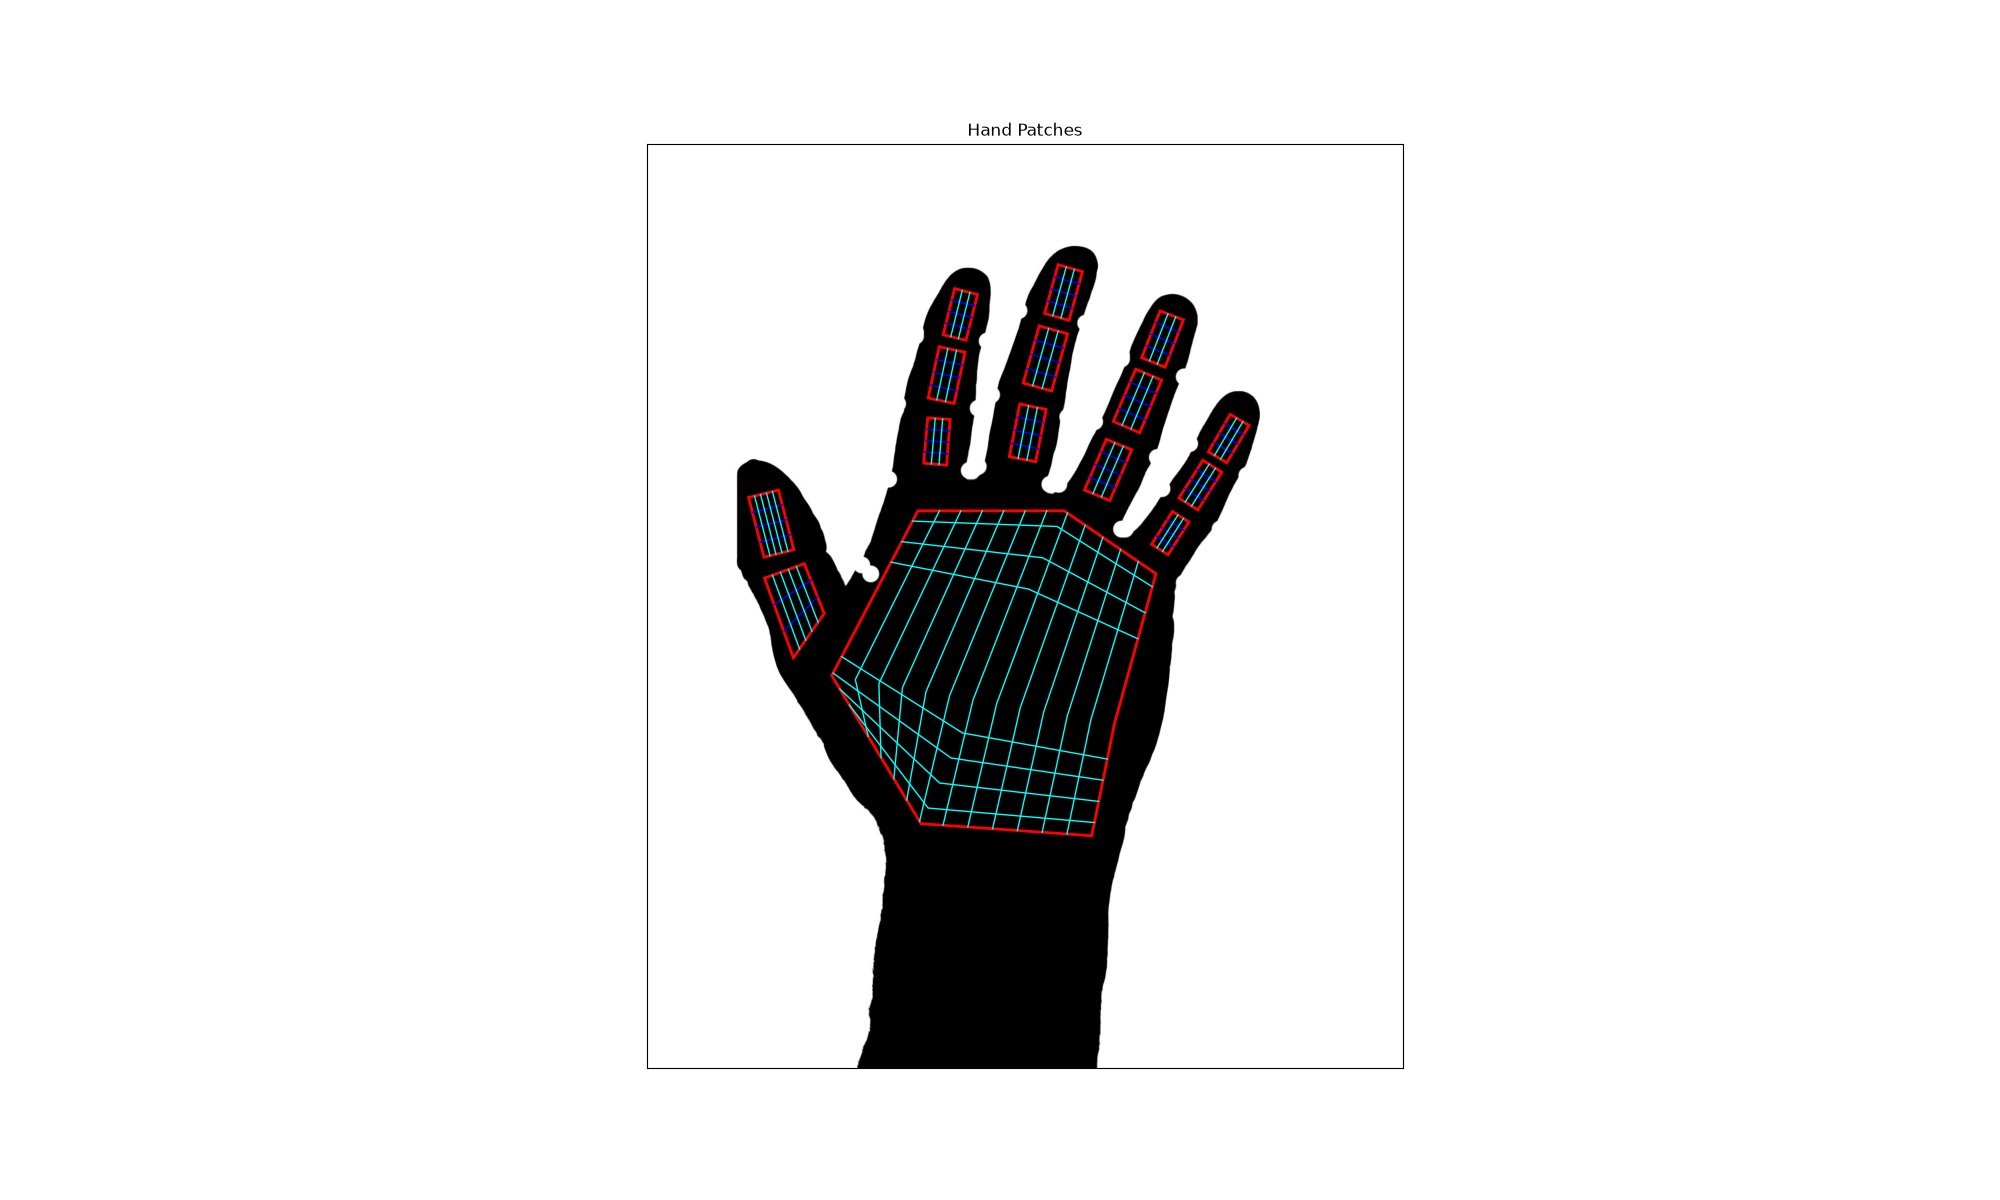

In [12]:
import matplotlib.patches as patches
import imageio.v2 as imageio

fig,ax = plt.subplots(figsize=(20,12))
electrode_traces = []
horizontal_traces = []
electrode_traces_other = []
vertical_traces = []
#fingerRegionDict: maps region -> (defining joint pair, polygon, horizontal traces, vertical traces)
fingerRegionDict = {}

for region in list(regionDict.keys()):
    p = regionDict[region][1]
    if region == 't1':
        pHorizontal = sample_and_connect_polygon_sides(p, num_points=5)
        pVertical = sample_and_connect_polygon_other_sides(p, num_points=6)
    elif region == 't2':
        pHorizontal = sample_and_connect_polygon_sides(p, num_points=4)
        pVertical = sample_and_connect_polygon_other_sides(p, num_points=6)
    else:
        pHorizontal = sample_and_connect_polygon_sides(p, num_points=5)
        pVertical = sample_and_connect_polygon_other_sides(p, num_points=4)
    electrode_traces.append(pHorizontal)
    horizontal_traces += pHorizontal
    electrode_traces_other.append(pVertical)
    vertical_traces += pVertical
    fingerRegionDict[region] = (regionDict[region][0], regionDict[region][1], pHorizontal, pVertical)
#colorCorrected = imageio.imread("croppedHandright0429.jpg")
colorCorrected = imageio.imread('/content/fpcb-glove-design/croppedHandleftmask.jpg')
mp_draw.draw_landmarks(colorCorrected, hand_landmarks, mp_hands.HAND_CONNECTIONS)
draw_finger_polygons_with_matplotlib(ax, mask, finger_rectangles, horizontal_traces, vertical_traces)
horizontalPalm, verticalPalm = sample_traces_palm(palmRegion)
draw_palm_traces(ax, horizontalPalm, verticalPalm)
polygon = patches.Polygon(palmRegion, closed=True, edgecolor='r', fill=False, linewidth=2)
horizontalFinal, verticalFinal = construct_final_traces(fingerRegionDict, horizontalPalm, verticalPalm)
# plotFinalTraces(ax, horizontalFinal, verticalFinal)
ax.add_patch(polygon)
ax.set_xticks([])  # Remove x-axis ticks
ax.set_yticks([])  # Remove y-axis ticks

plt.title("Hand Patches")
# plt.savefig("antheaElectrodes.svg")
plt.show()

## Extrude the contour and connect all traces

In [13]:
def extrude_contour(vertices, extrusion_distance):
    """
    Extrudes the contour outward by a given distance based on local normals.
    :param vertices: Nx2 array of contour vertices (x, y).
    :param extrusion_distance: Distance to extrude outward.
    :return: Extruded contour vertices (Nx2 array).
    """
    vertices = np.asarray(vertices)
    num_vertices = len(vertices)

    extruded_vertices = []
    for i in range(num_vertices):
        prev_vertex = vertices[i - 1]
        curr_vertex = vertices[i]
        next_vertex = vertices[(i + 1) % num_vertices]  # Wrap around

        tangent1 = curr_vertex - prev_vertex
        tangent2 = next_vertex - curr_vertex

        tangent1 /= np.linalg.norm(tangent1)
        tangent2 /= np.linalg.norm(tangent2)

        average_tangent = tangent1 + tangent2
        average_tangent /= np.linalg.norm(average_tangent)

        normal = np.array([-average_tangent[1], average_tangent[0]])

        extruded_vertex = curr_vertex + extrusion_distance * normal
        extruded_vertices.append(extruded_vertex)

    return np.array(extruded_vertices)

def line_intersection(p1, p2, p3, p4):
    """
    Calculate the intersection point of two line segments (p1-p2) and (p3-p4).
    :param p1, p2: Endpoints of the first line segment.
    :param p3, p4: Endpoints of the second line segment.
    :return: Intersection point (x, y) or None if no intersection.
    """
    # Line p1-p2 represented as a1x + b1y = c1
    a1 = p2[1] - p1[1]
    b1 = p1[0] - p2[0]
    c1 = a1 * p1[0] + b1 * p1[1]

    # Line p3-p4 represented as a2x + b2y = c2
    a2 = p4[1] - p3[1]
    b2 = p3[0] - p4[0]
    c2 = a2 * p3[0] + b2 * p3[1]

    determinant = a1 * b2 - a2 * b1

    if determinant == 0:
        return None  # Lines are parallel or coincident

    # Compute the intersection point
    intersect_x = (b2 * c1 - b1 * c2) / determinant
    intersect_y = (a1 * c2 - a2 * c1) / determinant

    # Check if the intersection point is within the bounds of both segments
    if (min(p1[0], p2[0]) <= intersect_x <= max(p1[0], p2[0]) and
        min(p1[1], p2[1]) <= intersect_y <= max(p1[1], p1[1]) and
        min(p3[0], p4[0]) <= intersect_x <= max(p3[0], p4[0]) and
        min(p3[1], p4[1]) <= intersect_y <= max(p3[1], p4[1])):
        return np.array([intersect_x, intersect_y])

    return None

def remove_self_intersections(vertices):
    """
    Iteratively removes self-intersections by replacing the intersection points with the intersection itself.
    :param vertices: Nx2 array of contour vertices (x, y).
    :return: Cleaned contour vertices (Nx2 array).
    """
    num_vertices = len(vertices)
    new_vertices = vertices
    intersections_found = True

    while intersections_found:
        intersections_found = False
        for i in range(num_vertices):
            for j in range(i+2, num_vertices - (i == 0)):  # Avoid adjacent edges and wrap around
                p1, p2 = vertices[i], vertices[(i + 1) % num_vertices]
                p3, p4 = vertices[j], vertices[(j + 1) % num_vertices]

                intersection = line_intersection(p1, p2, p3, p4)
                if intersection is not None:
                    # Replace the intersecting vertices with the intersection point
                    new_vertices[i] = intersection
                    new_vertices[(i + 1) % num_vertices] = intersection
                    intersections_found = True
                    break  # Stop checking other intersections once one is found
            if intersections_found:
                break  # Stop checking if we found an intersection

        # Update vertices for the next iteration
        vertices = np.array(new_vertices)

    return np.array(new_vertices)

def intrude_contour(vertices, extrusion_distance):
    """
    Extrudes the contour outward by a given distance based on local normals,
    and removes any self-intersections by replacing them with the intersected point itself.
    :param vertices: Nx2 array of contour vertices (x, y).
    :param extrusion_distance: Distance to extrude outward.
    :return: Extruded and intersection-free contour vertices (Nx2 array).
    """
    vertices = np.asarray(vertices)
    num_vertices = len(vertices)

    # Step 1: Extrude the contour
    extruded_vertices = []
    for i in range(num_vertices):
        prev_vertex = vertices[i - 1]
        curr_vertex = vertices[i]
        next_vertex = vertices[(i + 1) % num_vertices]  # Wrap around

        tangent1 = curr_vertex - prev_vertex
        tangent2 = next_vertex - curr_vertex

        # Check if the tangent vectors have zero length
        norm_tangent1 = np.linalg.norm(tangent1)
        norm_tangent2 = np.linalg.norm(tangent2)

        if norm_tangent1 == 0 or norm_tangent2 == 0:
            continue  # Skip this iteration if a tangent has zero length

        # Normalize the tangent vectors
        tangent1 /= norm_tangent1
        tangent2 /= norm_tangent2

        # Average tangent
        average_tangent = tangent1 + tangent2
        average_tangent /= np.linalg.norm(average_tangent)  # Normalize the average tangent

        normal = np.array([-average_tangent[1], average_tangent[0]])  # Perpendicular to the tangent

        extruded_vertex = curr_vertex - extrusion_distance * normal
        extruded_vertices.append(extruded_vertex)

    # Step 2: Remove self-intersections iteratively
    extruded_vertices = remove_self_intersections(extruded_vertices)

    return np.array(extruded_vertices)



def extrude_concave_shape(vertices, extrusion_distance, resolution=None, num_points=None):
    """
    Extrudes a concave shape by a specified distance.
    :param vertices: Nx2 array of contour vertices (x, y).
    :param extrusion_distance: Distance to extrude outward.
    :return: Extruded contour vertices (Nx2 array).
    """
    # Convert the vertices into a Shapely Polygon
    polygon = shapPolygon(vertices)

    # Perform the buffer operation for extrusion
    buffered = polygon.buffer(extrusion_distance)
    # If the buffer creates a MultiPolygon, select the largest one
    if isinstance(buffered, MultiPolygon):
        extruded_polygon = max(buffered.geoms, key=lambda p: p.area)
    else:
        extruded_polygon = buffered
    lower_left = Point(vertices[0])

    nearest_pt = Point(min(extruded_polygon.exterior.coords,
                  key=lambda x: Point(x).distance(lower_left)))
    # Get the exterior coordinates of the extruded shape
    # extruded_vertices = np.array(extruded_polygon.exterior.coords)

    perimeter = extruded_polygon.exterior.coords
    new_coords = []
    first_vertex = nearest_pt  # as found in the question above
    print(first_vertex)
    two_tours = itertools.chain(perimeter[:-1], perimeter)
    for v in two_tours:
        if Point(v) == first_vertex:
            new_coords.append(v)
            while len(new_coords) < len(perimeter):
                new_coords.append(next(two_tours))
            break
    polygon = shapPolygon(new_coords)
    # extruded_vertices = np.array(polygon.exterior.coords)

    if resolution:
        # Generate points based on fixed resolution
        num_points = int(polygon.exterior.length / resolution)
    elif not num_points:
        # Default to using the number of input vertices if no resolution or num_points provided
        num_points = len(vertices)

    # Interpolate points along the exterior
    uniform_coords = [
        polygon.exterior.interpolate(i / num_points, normalized=True).coords[0]
        for i in range(num_points)
    ]

    # Ensure it forms a closed loop if necessary
    if uniform_coords[0] != uniform_coords[-1]:
        uniform_coords.append(uniform_coords[0])

    return np.array(uniform_coords)


    # return extruded_vertices


def extrude_outward(mask, extrusion_distance):
    """
    Extrude a binary mask outward by a specified distance.
    :param mask: 2D numpy array (binary mask where 1s represent the hand).
    :param extrusion_distance: Distance to extrude outward (in pixels).
    :return: 2D numpy array of the outward-extruded mask.
    """
    kernel_size = int(extrusion_distance * 2 + 1)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    extruded_mask = cv2.dilate(mask, kernel)
    return extruded_mask

def extrude_inward(mask, extrusion_distance):
    """
    Extrude a binary mask inward by a specified distance.
    :param mask: 2D numpy array (binary mask where 1s represent the hand).
    :param extrusion_distance: Distance to extrude inward (in pixels).
    :return: 2D numpy array of the inward-extruded mask.
    """
    kernel_size = int(extrusion_distance * 2 + 1)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    extruded_mask = cv2.erode(mask, kernel)
    return extruded_mask

def create_coverlay_opening(edge, distance):
    return extrude_concave_shape(edge, -distance)



POINT (503.7684323550465 1439.7315676449534)
POINT (481.5 1461)
POINT (482.8292770221904 1459.6707229778096)
POINT (484.1585540443808 1458.3414459556193)
POINT (485.48783106657123 1457.0121689334287)
POINT (486.81710808876164 1455.6828919112384)
POINT (488.14638511095205 1454.353614889048)
POINT (489.47566213314246 1453.0243378668576)
POINT (490.8049391553329 1451.695060844667)
POINT (492.1342161775233 1450.3657838224767)
POINT (493.4634931997137 1449.0365068002864)
POINT (495.0895169006391 1447.707229778096)
POINT (496.74420296936614 1446.3779527559054)
POINT (498.3045514160546 1445.048675733715)
POINT (499.7473911801168 1443.7193987115247)
POINT (501.1098783106657 1442.3901216893344)
POINT (502.4391553328561 1441.0608446671438)
POINT (939.5 1461)
POINT (938.9493954292577 1459.6707229778096)
POINT (937.8414459556192 1458.3414459556193)
POINT (936.5410832781579 1457.0121689334287)
POINT (935.4994916446157 1455.6828919112384)
POINT (934.6364848723184 1454.353614889048)
POINT (933.580556

/tmp/ipykernel_20929/154579356.py:309: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


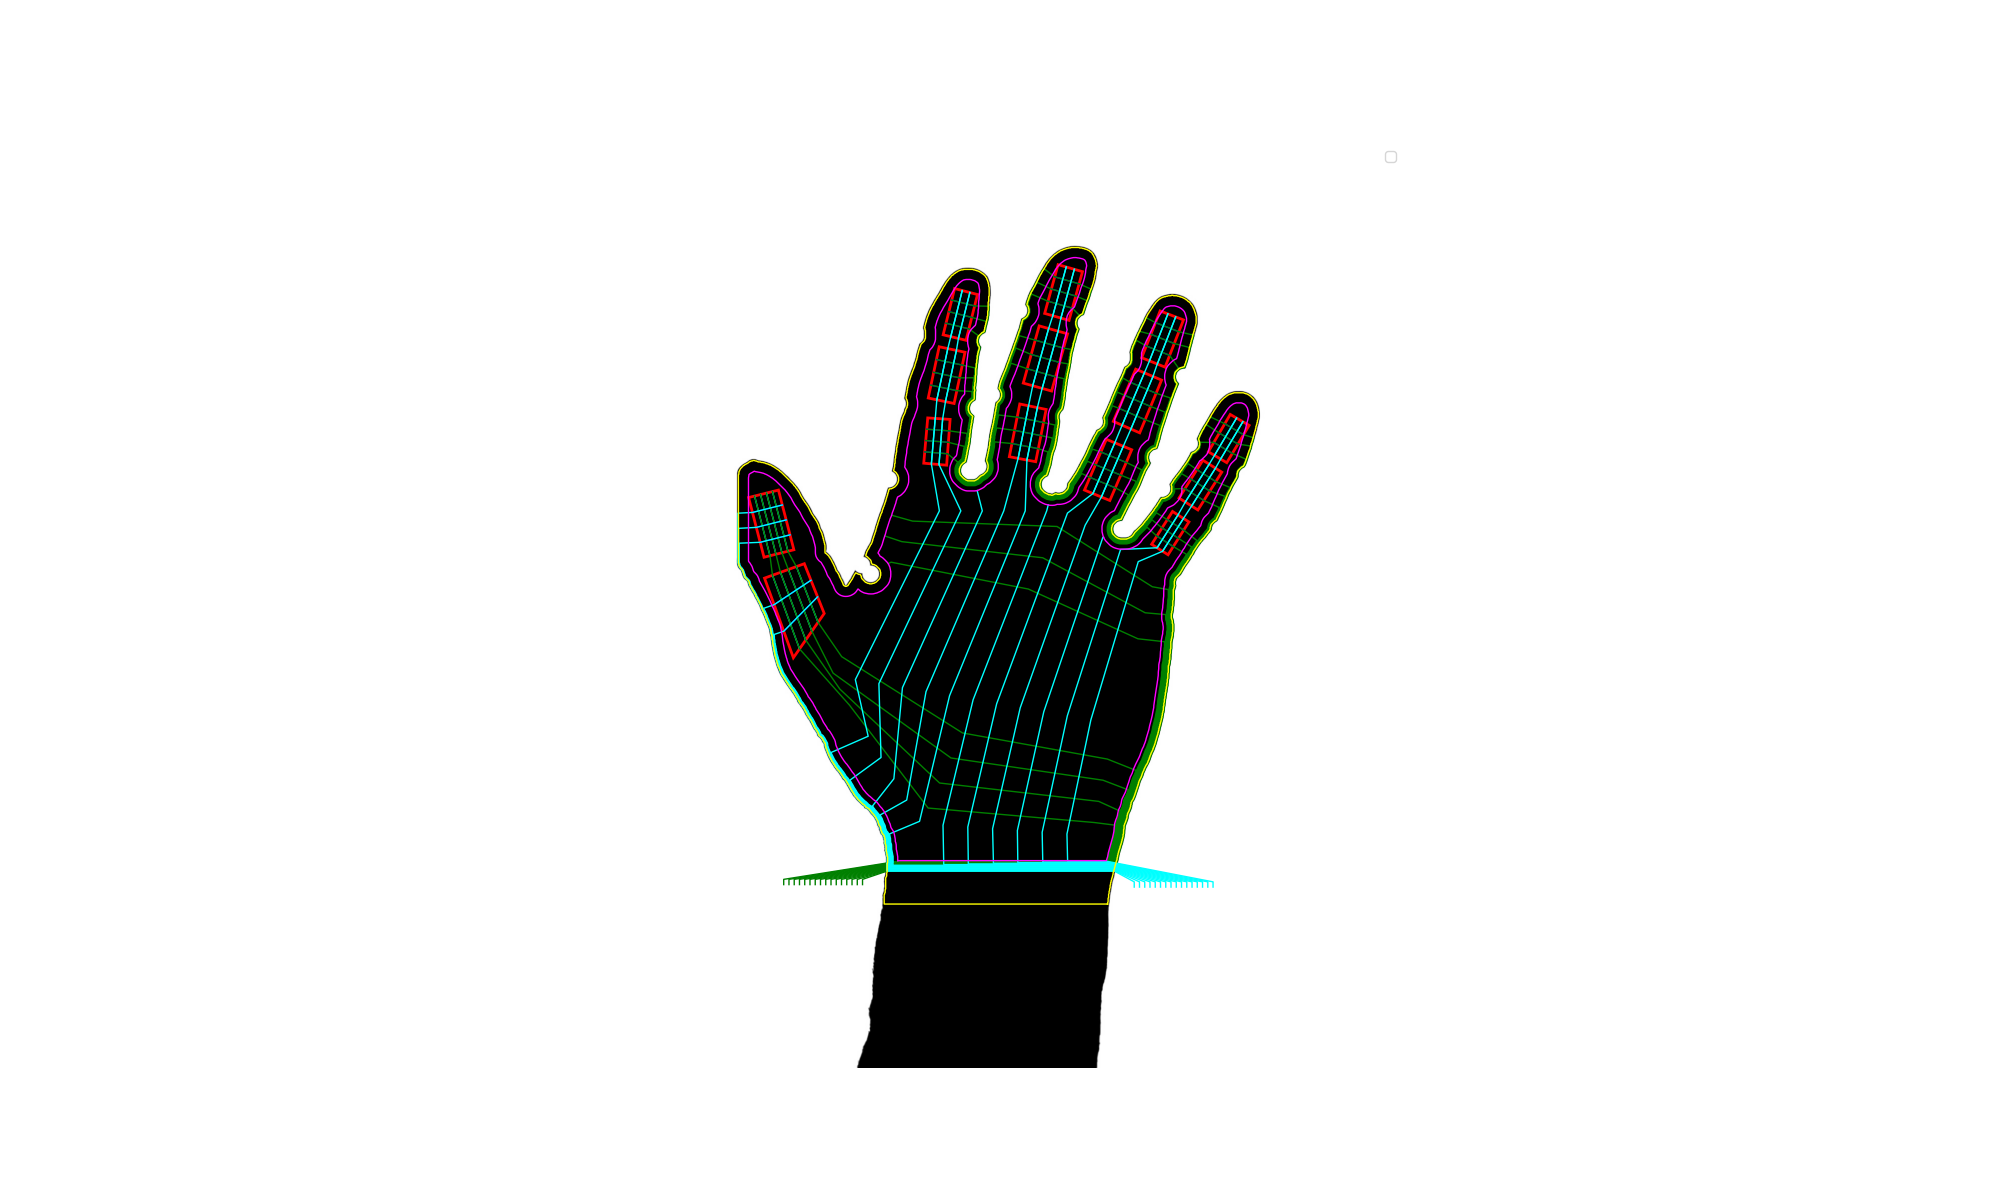

In [23]:

from shapely.geometry import Polygon as shapPolygon
from shapely.geometry import MultiPolygon
from shapely.geometry import Point
import itertools

min_trace_spacing = 0.020
outer_edge_spacing = 0.05

def point_to_segment_distance_np(points, A, B):
    """Calculate the minimum distance from points to a line segment AB."""
    A = np.asarray(A)
    B = np.asarray(B)
    points = np.atleast_2d(points)  # Ensure 2D array

    AB = B - A
    AB_squared = np.dot(AB, AB)
    if AB_squared == 0:
        # A and B are the same point
        return np.linalg.norm(points - A, axis=1)

    # Parametric t for projection on AB
    AP = points - A
    t = np.clip(np.sum(AP * AB, axis=1) / AB_squared, 0, 1)
    projections = A + t[:, np.newaxis] * AB

    return np.linalg.norm(points - projections, axis=1)

def is_below_segment(points, A, B):
    """Check if points are 'below' the line segment AB using the cross product."""
    A = np.asarray(A)
    B = np.asarray(B)
    points = np.atleast_2d(points)

    AB = B - A
    AP = points - A

    # Cross product in 2D: z = x1*y2 - y1*x2
    cross_products = AB[0] * AP[:, 1] - AB[1] * AP[:, 0]
    return cross_products < 0  # True if 'below'

def closest_point_with_condition_np(track, point, A, B, min_distance=0.7):
    """Find the closest point on the track to 'point' that is at least
    'min_distance' below the line segment AB."""
    track = np.asarray(track[:len(track)//2])  # Use first half of the track
    distances_to_segment = point_to_segment_distance_np(track, A, B)
    below_segment_mask = is_below_segment(track, A, B)
    below_point_mask = track[:,1]>point[1]
    valid_points = track[(distances_to_segment >= min_distance) & below_segment_mask & below_point_mask]

    if valid_points.size == 0:
        return None  # No point satisfies the condition

    distances_to_point = np.linalg.norm(valid_points - point, axis=1)
    return valid_points[np.argmin(distances_to_point)]





def sample_track(ax3, fingerRegionDict, handEdge, boundary, horizontalPalm, verticalPalm, smoothedEdge, extrusionDist=2):
    horizontalTraces = []
    intrudedContours = []
    intrudedContours2 = []
    thisEdge = smoothedEdge[::-1]
    thisEdge = thisEdge[:, [1, 0]]
    coverlay = create_coverlay_opening(thisEdge,distance=16*extrusionDist)
    for i in range(16):
        nextContour = extrude_concave_shape(thisEdge, -extrusionDist*i)
        intrudedContours.append(nextContour.copy())
    for i in range(16):
        nextContour = extrude_concave_shape(smoothedEdge[:,[1,0]], -extrusionDist*i)
        intrudedContours2.append(nextContour.copy())
    for i in range(9):
        # v2_inner = extrude_inward(handEdge, 0.7*(8-i))
        # inner_target_l, _ = contour_hand(v2_inner, boundary)
        inner_target_l = intrudedContours[8-i]
        revisedHorizontalIndex = 8-i
        # inner_target_l = inner_target_l[::-1]
        track=inner_target_l
        # if i == 0:
        #     ax3.scatter(track[:,0],track[:,1], color='magenta')
        for j in range(5,1,-1):
            patch = 'd'+str(j)+'p'+ str(3-i//3)
            electrode = i%3
            two_points = np.array(fingerRegionDict[patch][2][::-1][electrode])
            # if i == 0 and j == 5:
            #     print(two_points)
            #     ax3.scatter(two_points[:,0], two_points[:,1])

            # find closest point on inner_target_l to each point, and create new track where each point in two_points
            # is connected to its closest point, and all points in between the two closest points are removed
            # (ie, closestPoint1, twoPoints1, twoPoints2, closestPoint2)
            # Find the closest points on `inner_target_l` to each point in `two_points`
            closest_points = []
            for point in two_points:
                closest_point = min(track, key=lambda p: euclidean_distance(point, p))
                closest_points.append(closest_point)
            if i == 0 and j == 5:
                print(closest_points)
                # ax3.scatter(np.array(closest_points)[:,0], np.array(closest_points)[:,1])

            # Get indices of the closest points in `inner_target_l`
            closest_indices = [np.where((track == cp).all(axis=1))[0][0] for cp in closest_points]
            closest_indices.sort()  # Sort indices to maintain order

            idx_start, idx_end = closest_indices
            if j==2:
                track = np.concatenate((track[:idx_start + 1], two_points[::-1]))
            else:
                track = np.concatenate((track[:idx_start + 1], two_points[::-1], track[idx_end:]))
        horizontalTraces.append((track,revisedHorizontalIndex))

    #Connect horizontal traces on palm
    horizontalOrdered = np.array(horizontalPalm)[::-1]
    for i in range(9, 16):
        # v2_inner = extrude_inward(handEdge, 0.7*i)
        # inner_target_l, _ = contour_hand(v2_inner, boundary)
        inner_target_l = intrudedContours[i]
        # inner_target_l = inner_target_l[::-1]
        track=inner_target_l
        point = horizontalOrdered[i-9][0]
        closest_point = min(track[:len(track)//2], key=lambda p: euclidean_distance(point, p))
        closestIdx = np.where((track == closest_point).all(axis=1))[0][0]
        if i >= 12:
            track = np.concatenate((track[:closestIdx], horizontalOrdered[i-9],  fingerRegionDict['t2'][3][15-i][::-1], fingerRegionDict['t1'][3][15-i][::-1]))
        else:
            point2 = horizontalOrdered[i-9][-1]
            closest_2 = min(coverlay, key=lambda p: euclidean_distance(point2, p))
            track = np.vstack((track[:closestIdx], horizontalOrdered[i-9], closest_2))
        horizontalTraces.append((track,i))

    verticalTraces = []
    #Vertical thumb
    for i in range(0,5):
        # v2_inner = extrude_inward(handEdge, 0.7*i)
        # inner_target_l, _ = contour_hand(v2_inner, boundary)

        inner_target_l = intrudedContours2[i]
        track=inner_target_l[::-1]
        if i < 3:
            electrode = fingerRegionDict['t1'][2][i]
        else:
            electrode = fingerRegionDict['t2'][2][i-3]
        point = electrode[0]
        closest_point = min(track, key=lambda p: euclidean_distance(point, p))
        closestIdx = np.where((track == closest_point).all(axis=1))[0][0]
        track = np.concatenate((track[:closestIdx], electrode))
        verticalTraces.append((track,i))
    for i in range(10, -1, -1):
        inner_target_l = intrudedContours2[15-i]
        track=inner_target_l[::-1]
        # ax3.scatter(track[0,0], track[0,1])
        point = verticalPalm[i][0]
        #Look only for point on the left part of the hand
        if i > 5:
            closest_point = min(track[:len(track)//2], key=lambda p: euclidean_distance(point, p))
            prevA, prevB = point, closest_point
        else:
            closest_point = closest_point_with_condition_np(track, point, prevA,prevB, min_distance=8)
            prevA, prevB = point, closest_point

        closestIdx = np.where((track == closest_point).all(axis=1))[0][0]
        if i == 0:
            trace = np.vstack([track[:closestIdx],verticalPalm[i],fingerRegionDict['d5p3'][3][1][::-1],fingerRegionDict['d5p2'][3][1][::-1],fingerRegionDict['d5p1'][3][1][::-1]])
        elif i == 1:
            trace = np.vstack([track[:closestIdx],verticalPalm[i], fingerRegionDict['d5p3'][3][0][::-1], fingerRegionDict['d5p2'][3][0][::-1], fingerRegionDict['d5p1'][3][0][::-1]])
        elif i == 3:
            trace = np.vstack([track[:closestIdx], verticalPalm[i], fingerRegionDict['d4p3'][3][1][::-1], fingerRegionDict['d4p2'][3][1][::-1], fingerRegionDict['d4p1'][3][1][::-1]])
        elif i == 4:
            trace = np.vstack([track[:closestIdx], verticalPalm[i], fingerRegionDict['d4p3'][3][0][::-1], fingerRegionDict['d4p2'][3][0][::-1] , fingerRegionDict['d4p1'][3][0][::-1]])
        elif i == 6:
            trace = np.vstack([track[:closestIdx], verticalPalm[i], fingerRegionDict['d3p3'][3][1][::-1], fingerRegionDict['d3p2'][3][1][::-1], fingerRegionDict['d3p1'][3][1][::-1]])
        elif i == 7:
            trace = np.vstack([track[:closestIdx], verticalPalm[i], fingerRegionDict['d3p3'][3][0][::-1], fingerRegionDict['d3p2'][3][0][::-1], fingerRegionDict['d3p1'][3][0][::-1]])
        elif i == 9:
            trace = np.vstack([track[:closestIdx], verticalPalm[i], fingerRegionDict['d2p3'][3][1][::-1], fingerRegionDict['d2p2'][3][1][::-1], fingerRegionDict['d2p1'][3][1][::-1]])
        elif i == 10:
            trace = np.vstack([track[:closestIdx], verticalPalm[i], fingerRegionDict['d2p3'][3][0][::-1], fingerRegionDict['d2p2'][3][0][::-1], fingerRegionDict['d2p1'][3][0][::-1]])
        else:
            point2 = verticalPalm[i][-1]
            closest_2 = min(coverlay, key=lambda p: euclidean_distance(point2, p))
            trace = np.vstack((track[:closestIdx], verticalPalm[i], closest_2))
        verticalTraces.append((trace,15-i))

    #connect convex hull of the sensing patches to the innermost hand outline extrusion for the coverlay opening
    # for j in range(5,0,-1):
    #     if j!=1:
    #         patch = 'd'+str(j)+'p'
    #         bottomRight = fingerRegionDict[patch+"3"][1][2]
    #         bottomLeft = fingerRegionDict[patch+"3"][1][3]
    #         closestPointRight = min(coverlay, key=lambda p: euclidean_distance(bottomRight, p))
    #         closestPointLeft = min(coverlay, key=lambda p: euclidean_distance(bottomLeft, p))
    #         closestLeft = np.where((coverlay == closestPointLeft).all(axis=1))[0][0]
    #         closestRight = np.where((coverlay == closestPointRight).all(axis=1))[0][0]
    #         coverlay = np.vstack((coverlay[:closestRight+1], bottomRight, fingerRegionDict[patch+"3"][1][1],
    #                                 fingerRegionDict[patch+"2"][1][2], fingerRegionDict[patch+"2"][1][1],
    #                                 fingerRegionDict[patch+"1"][1][2], fingerRegionDict[patch+"1"][1][1],
    #                                 fingerRegionDict[patch+"1"][1][0], fingerRegionDict[patch+"1"][1][3],
    #                                 fingerRegionDict[patch+"2"][1][0], fingerRegionDict[patch+"2"][1][3],
    #                                 fingerRegionDict[patch+"3"][1][0], bottomLeft, coverlay[closestLeft:]))
    #     else:
    #         patch = 't'
    #         bottomRight = fingerRegionDict[patch+"2"][1][2]
    #         bottomLeft = fingerRegionDict[patch+"2"][1][3]
    #         closestPointRight = min(coverlay, key=lambda p: euclidean_distance(bottomRight, p))
    #         closestPointLeft = min(coverlay, key=lambda p: euclidean_distance(bottomLeft, p))
    #         closestLeft = np.where((coverlay == closestPointLeft).all(axis=1))[0][0]
    #         closestRight = np.where((coverlay == closestPointRight).all(axis=1))[0][0]
    #         coverlay = np.vstack((coverlay[:closestRight+1], bottomRight, fingerRegionDict[patch+"2"][1][1],
    #                                 fingerRegionDict[patch+"1"][1][2], fingerRegionDict[patch+"1"][1][1],
    #                                 fingerRegionDict[patch+"1"][1][0], fingerRegionDict[patch+"1"][1][3],
    #                                 fingerRegionDict[patch+"2"][1][0], bottomLeft, coverlay[closestLeft:]))
    horizontal_traces = [sortedTrace[0] for sortedTrace in sorted(horizontalTraces, key=lambda x:x[1])]
    vertical_traces = [sortedTrace[0] for sortedTrace in sorted(verticalTraces, key=lambda x:x[1])]
    return horizontal_traces, vertical_traces, coverlay

def plotTraces(ax, traceList, color='green'):
    for trace in traceList:
        ax.plot([trace[i][0] for i in range(len(trace))], [trace[i][1] for i in range(len(trace))], color, linewidth=1)


fig, ax = plt.subplots(figsize=(20,12))
ax.set_axis_off()
edgeCutNew = extrude_outward(smoothed_v2, outer_edge_spacing*pixels_per_cm_height/2)
boundary = int(y * mask.shape[0]+pixels_per_cm_height*1)
outer_edge_new, l_inner_target_new = contour_hand(edgeCutNew, boundary, num_points=5000)

newTracks, verticalTracks, coverlay = sample_track(ax, fingerRegionDict,smoothed_v2,boundary, horizontalPalm, verticalPalm, outer_edge_new, extrusionDist=min_trace_spacing*pixels_per_cm_height)
# draw_finger_polygons_with_matplotlib(ax3, binary_image, finger_rectangles)
draw_finger_polygons_with_matplotlib(ax, binary_image,  finger_rectangles, horizontal_traces, vertical_traces)

edgeCut = extrude_outward(smoothed_v2, outer_edge_spacing*pixels_per_cm_height)
boundaryEdge = int(y * mask.shape[0]+pixels_per_cm_height*2)
outer_target, l_inner_target = contour_hand(edgeCut, boundaryEdge, num_points=5000)
outer_target = outer_target[:,[1,0]]

#def extend_tracks_to_via(contour, horizontal, vertical, startDistance=1.0*pixels_per_cm_height, startWidth=0.7*pixels_per_cm_height):
#    viaSpacing = 0.13 * pixels_per_cm_width

def extend_tracks_to_via(contour, horizontal, vertical, startDistance=0.7*pixels_per_cm_height, startWidth=0.7*pixels_per_cm_height):
    viaSpacing = 0.15 * pixels_per_cm_width

    def get_point_along_contour(contour, distance, from_start=True):
        """Get a point along the contour at a specified distance from start or end."""
        segment_lengths = np.linalg.norm(np.diff(contour, axis=0), axis=1)
        cumulative_lengths = np.cumsum(segment_lengths)
        total_length = cumulative_lengths[-1]

        if distance > total_length:
            raise ValueError("Distance exceeds the contour length.")

        if from_start:
            idx = np.searchsorted(cumulative_lengths, distance)
            prev_length = cumulative_lengths[idx - 1] if idx > 0 else 0
            t = (distance - prev_length) / segment_lengths[idx]
            return contour[idx] + t * (contour[idx + 1] - contour[idx])
        else:
            reversed_lengths = total_length - cumulative_lengths
            idx = np.searchsorted(reversed_lengths[::-1], distance)
            prev_length = reversed_lengths[-(idx + 1)] if idx > 0 else 0
            t = (distance - prev_length) / segment_lengths[-(idx + 1)]
            return contour[-(idx + 2)] + t * (contour[-(idx + 1)] - contour[-(idx + 2)])

    # Get the starting points along the contour
    startContour = get_point_along_contour(contour, startDistance, from_start=True)
    endContour = get_point_along_contour(contour, startDistance, from_start=False)

    # Generate new via points for vertical tracks
    vertical_vias = np.array([
        startContour + np.array([startWidth + i * viaSpacing, 0])
        for i in range(len(vertical))
    ])

    # Generate new via points for horizontal tracks
    horizontal_vias = np.array([
        endContour + np.array([-startWidth - i * viaSpacing, 0])
        for i in range(len(horizontal))
    ])

    # Connect each vertical track to its via point
    vertical_tracks = []
    for track, via_point in zip(vertical, vertical_vias):
        vertical_tracks.append(np.vstack([np.array([via_point[0],via_point[1]+viaSpacing]),via_point,track]))

    # Connect each horizontal track to its via point
    horizontal_tracks = []
    for track, via_point in zip(horizontal, horizontal_vias):
        horizontal_tracks.append(np.vstack([np.array([via_point[0],via_point[1]+viaSpacing]),via_point,track]))

    return {
        'vertical_tracks': vertical_tracks,
        'horizontal_tracks': horizontal_tracks,
        'vertical_vias': vertical_vias,
        'horizontal_vias': horizontal_vias
    }
outDict = extend_tracks_to_via(outer_target, newTracks, verticalTracks)

# outer_target = reflect_thumb(outer_target[:,[1,0]], red_joint, purple_joint)
edgeCut = np.vstack((outer_target, outer_target[0, :]))



plotTraces(ax, outDict['horizontal_tracks'])
plotTraces(ax, outDict['vertical_tracks'],'cyan')
plotTraces(ax, [edgeCut], 'yellow')
plotTraces(ax, [coverlay],'magenta')


ax.legend()
plt.savefig("alllayers.svg")


## Write SVG and KiCad Mod

In [15]:
#Fix routing to horizontal thumb traces
#Wider top thumb patch
#


def scale_coordinates(points, pixels_per_cm_width, pixels_per_cm_height):
    """
    Scale a list of (x, y) points from pixels to centimeters.

    Args:
        points (list of tuples): List of (x, y) tuples representing points in pixels.
        pixels_per_cm_width (float): Conversion factor from pixels to cm along the width.
        pixels_per_cm_height (float): Conversion factor from pixels to cm along the height.

    Returns:
        list of tuples: List of (x, y) tuples representing the scaled points in centimeters.
    """
    return [(x*(pixels_per_cm_width), y*(pixels_per_cm_height)) for x, y in points]

def create_outline_path(points, thickness, dwg):
    """
    Create an SVG with a true outline of a path.

    Args:
        points (list of tuples): List of (x, y) points defining the original path.
        thickness (float): Thickness of the outline.
        dwg (svgwrite.Drawing): The SVG drawing object.

    Returns:
        outline_polygon (svgwrite.Polygon): The created outline path and outline (geometry)
    """
    # Create the original path as a LineString
    path = LineString(points)

    # Buffer the path to create an outline (shapely handles offsetting)
    outline = path.buffer(thickness / 2, cap_style=2, join_style=2)  # Thickness/2 because buffer expands both sides

    # Ensure the outline is oriented correctly
    outline = orient(outline, sign=1.0)

    # Extract exterior points from the buffered polygon
    if not isinstance(outline, shapPolygon):
        raise ValueError("Buffer operation failed; the result is not a Polygon.")

    exterior_points = list(outline.exterior.coords)
    # Add the outline polygon to the SVG
    outline_polygon = dwg.polygon(points=exterior_points, fill="black", stroke="none")
    return outline_polygon, outline

def add_polygon_to_svg(dwg, group, polygon, stroke="none", fill="black"):
    coords = list(polygon.exterior.coords)
    group.add(dwg.polygon(points=coords, stroke=stroke, fill=fill))

def save_paths(image, vertical_traces, horizontal_traces, edgeCut, coverlaymask, finger_rectangles, palmRegion):
    """
    Save multiple paths in a grouped structure in an SVG file, scaling from pixels to centimeters.

    Args:
        image (ndarray): The image array for setting SVG size.
        vertical_traces (list of list of tuples): List of (x, y) tuples for vertical paths.
        horizontal_traces (list of list of tuples): List of (x, y) tuples for horizontal paths.
        edgeCut (list of tuples): List of (x, y) points for the edge cut polygon.
        coverlaymask (list of tuples): List of (x, y) points for the coverlay mask.
        pixels_per_cm_width (float): Conversion factor from pixels to cm along the width.
        pixels_per_cm_height (float): Conversion factor from pixels to cm along the height.
    """
    newScaleY = 11*96/image.shape[0]
    newScaleX = 8.5*96/image.shape[1]
    print(newScaleY, newScaleX)
    dwgFront = svgwrite.Drawing("handFront.svg")
    dwgBack = svgwrite.Drawing("handBack.svg")

    thickness = 0.40  # Scaling factor for line thickness
    frontCopperPolygons=[]
    backCopperPolygons=[]

    # Create groups for the paths
    frontCopper = dwgFront.g(id="F.Cu", fill="black", stroke="none")
    backCopper = dwgBack.g(id="B.Cu", fill="black", stroke="none")
    frontcuts = dwgFront.g(id="Edge.Cuts", fill="gray", stroke="none")
    backCuts = dwgBack.g(id="Edge.Cuts", fill="gray", stroke="none")
    frontmask = dwgFront.g(id="F.Mask", fill="black", stroke="none")
    backmask = dwgBack.g(id="B.Mask", fill="black", stroke="none")
    adhesiveFront = dwgFront.g(id="Eco1.User", fill="black", stroke="none")
    adhesiveBack = dwgBack.g(id="Eco1.User", fill="black", stroke="none")

    # Scale and add each vertical trace after outlining
    for i, path_points in enumerate(vertical_traces):
        #7, 10, 13
        path_points = scale_coordinates(path_points, newScaleX, newScaleY)
        fullPath, outlinePolygon = create_outline_path(path_points, thickness, dwgFront)
        if i in [7, 10, 13]:
            outlinedPath,_ = create_outline_path(path_points[:-1], thickness, dwgFront)
        else:
            outlinedPath = fullPath
        frontCopperPolygons.append(outlinePolygon)
        frontCopper.add(outlinedPath)

    # Scale and add each horizontal trace after outlining
    for i, path_points in enumerate(horizontal_traces):
        #9, 10, 11
        path_points = scale_coordinates(path_points, newScaleX, newScaleY)
        fullPath,outlinePolygon = create_outline_path(path_points, thickness, dwgBack)
        if i in [9,10,11]:
            outlinedPath,_ = create_outline_path(path_points[:-1], thickness, dwgBack)
        else:
            outlinedPath = fullPath
        backCopperPolygons.append(outlinePolygon)
        backCopper.add(outlinedPath)

    for polygon_points in finger_rectangles:
        maskPolygon = dwgFront.polygon(
            points=scale_coordinates(polygon_points, newScaleX, newScaleY),
            fill='black', stroke='none'
        )
        frontmask.add(maskPolygon)
        maskPolygon2 = dwgBack.polygon(
            points=scale_coordinates(polygon_points, newScaleX, newScaleY),
            fill='black', stroke='none'
        )
        backmask.add(maskPolygon2)

    # Scale and add the coverlay mask for the palm
    frontmaskLayer = dwgFront.polygon(
        points=scale_coordinates(palmRegion, newScaleX,newScaleY),
        fill='black', stroke='none')
    frontmask.add(frontmaskLayer)

    backmaskLayer = dwgBack.polygon(
        points=scale_coordinates(palmRegion, newScaleX, newScaleY),
        fill='black', stroke='none'
    )
    backmask.add(backmaskLayer)

    # Scale and add the coverlay mask
    # frontmaskLayer = dwgFront.polygon(
    #     points=scale_coordinates(coverlaymask, newScaleX,newScaleY),
    #     fill='black', stroke='none')
    # frontmask.add(frontmaskLayer)

    # backmaskLayer = dwgBack.polygon(
    #     points=scale_coordinates(coverlaymask, newScaleX, newScaleY),
    #     fill='black', stroke='none'
    # )
    # backmask.add(backmaskLayer)

    #Step 1: Join cyan and green polygons
    all_inner_polygons = unary_union(frontCopperPolygons + backCopperPolygons)
    maskPolygon = shapPolygon(scale_coordinates(coverlaymask, newScaleX,newScaleY))
    resulting_polygon = maskPolygon.difference(all_inner_polygons)
    innerPolygons = resulting_polygon.buffer(-2)
    print(type(innerPolygons))

    scaledEdge = scale_coordinates(edgeCut, newScaleX, newScaleY)


    # Scale and add the edge cut polygons
    edgeFront = dwgFront.polygon(
        points=scaledEdge,
        fill='black', stroke='none'
    )
    edgeBack = dwgBack.polygon(
        points=scaledEdge,
        fill='black', stroke='none'
    )


    frontcuts.add(edgeFront)
    backCuts.add(edgeBack)
    for extrudedInner in innerPolygons.geoms:
        print(type(extrudedInner))
        add_polygon_to_svg(dwgFront,frontcuts,extrudedInner)
        add_polygon_to_svg(dwgBack,backCuts,extrudedInner)
    print(scaledEdge[0],scaledEdge[-1])
    print(maskPolygon.exterior.coords[0],maskPolygon.exterior.coords[-1])
    edgePolygon = shapPolygon(scaledEdge)
    print(edgePolygon.exterior.coords[0], edgePolygon.exterior.coords[-1])
    result = edgePolygon.difference(maskPolygon)

    path_data = "M " + " L ".join(f"{x},{y}" for x, y in result.exterior.coords) + " Z"
    for hole in result.interiors:
        path_data += " M " + " L ".join(f"{x},{y}" for x, y in hole.coords) + " Z"

    # Add the path to the SVG
    adhesiveFront.add(dwgFront.path(d=path_data, fill="black", stroke="none"))
    adhesiveBack.add(dwgFront.path(d=path_data, fill="black", stroke="none"))

    # Add the groups to the SVGs
    dwgFront.add(frontCopper)
    dwgFront.add(frontcuts)
    dwgFront.add(frontmask)
    dwgFront.add(adhesiveFront)

    dwgBack.add(backCopper)
    dwgBack.add(backCuts)
    dwgBack.add(backmask)
    dwgBack.add(adhesiveBack)

    # Save the SVG files
    dwgFront.save()
    dwgBack.save()


save_paths(binary_image,outDict['vertical_tracks'], outDict['horizontal_tracks'], outer_target,coverlay, finger_rectangles, palmRegion)


def create_kicad_mod():
    # Load the SVG file
    for side in ["Front","Back"]:
        tree = etree.parse(f"hand{side}.svg")
        root = tree.getroot()

        # Define namespaces
        INKSCAPE_NS = "http://www.inkscape.org/namespaces/inkscape"

        # Add inkscape:label to all <g> elements with an id
        for g in root.findall(".//{http://www.w3.org/2000/svg}g"):
            group_id = g.get("id")
            if group_id:
                g.set(f"{{{INKSCAPE_NS}}}label", group_id)

        # Save to a new file
        tree.write(f"hand{side}New.svg", pretty_print=True, xml_declaration=True, encoding="UTF-8")
        imported = Svg2ModImport(
            f"hand{side}New.svg",
            "svg2mod",
            "G***",
            True,
            None
        )

        # Pick an output file name if none was provided:
        output_file_name = f"hand{side}.kicad_mod"

        # Create an exporter:
        exported = Svg2ModExportLatest(
            imported,
            output_file_name,
            False,
            1.0,
            5.0,
            dpi = DEFAULT_DPI,
            pads = False,
        )

        cmd_args = [os.path.basename(sys.argv[0])] + sys.argv[1:]
        cmdline = ' '.join(shlex.quote(x) for x in cmd_args)

        # Export the footprint:
        exported.write(cmdline)

create_kicad_mod()



0.568659127625202 0.5368421052631579
<class 'shapely.geometry.multipolygon.MultiPolygon'>
<class 'shapely.geometry.polygon.Polygon'>
<class 'shapely.geometry.polygon.Polygon'>
<class 'shapely.geometry.polygon.Polygon'>
<class 'shapely.geometry.polygon.Polygon'>
<class 'shapely.geometry.polygon.Polygon'>
<class 'shapely.geometry.polygon.Polygon'>
<class 'shapely.geometry.polygon.Polygon'>
<class 'shapely.geometry.polygon.Polygon'>
<class 'shapely.geometry.polygon.Polygon'>
<class 'shapely.geometry.polygon.Polygon'>
<class 'shapely.geometry.polygon.Polygon'>
<class 'shapely.geometry.polygon.Polygon'>
<class 'shapely.geometry.polygon.Polygon'>
<class 'shapely.geometry.polygon.Polygon'>
<class 'shapely.geometry.polygon.Polygon'>
<class 'shapely.geometry.polygon.Polygon'>
<class 'shapely.geometry.polygon.Polygon'>
<class 'shapely.geometry.polygon.Polygon'>
<class 'shapely.geometry.polygon.Polygon'>
<class 'shapely.geometry.polygon.Polygon'>
<class 'shapely.geometry.polygon.Polygon'>
<class 

INFO:svg2mod-unfiltered:Parsing SVG...


No handler for element {http://www.w3.org/2000/svg}defs


DEBUG:svg2mod:No handler for element {http://www.w3.org/2000/svg}defs


Document scaling: 1 units per pixel


...

INFO:svg2mod:  Writing Polygon with 5 points


  Writing Polygon with 9 points


INFO:svg2mod:  Writing Polygon with 9 points


  Writing Polygon with 6 points


INFO:svg2mod:  Writing Polygon with 6 points
